Mounted at /content/drive
Iniciando lectura de archivos...
Lectura completada. Total de registros cargados: 300


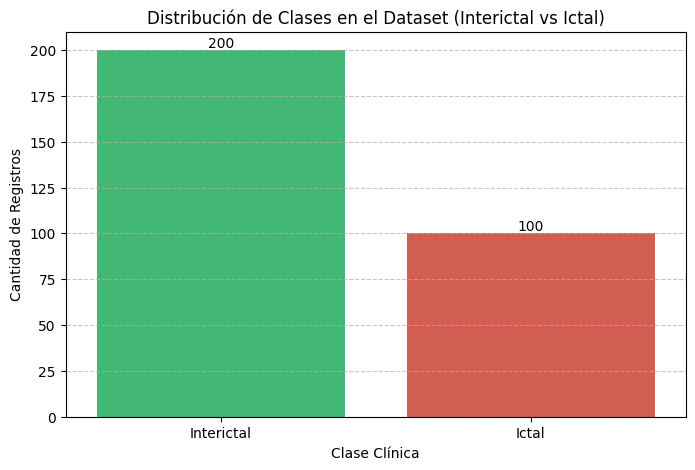

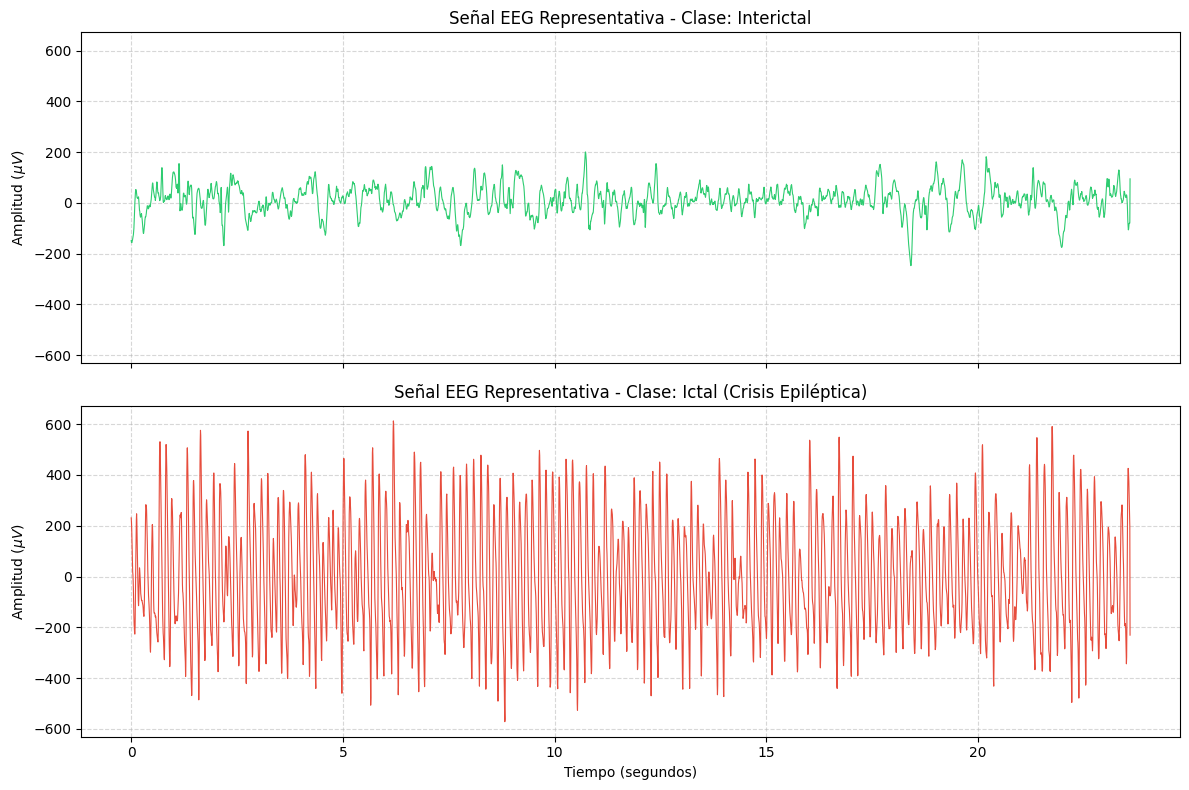


Generando tabla resumen de parámetros estadísticos...

Tabla Resumen de Parámetros Estadísticos (Media ± Desviación Estándar):


,Media,Desv_Estandar,Max_Amplitud,Varianza,Asimetria,Curtosis
Clase,,,,,,
Ictal,-4.75 ± 27.16,306.57 ± 147.96,910.05 ± 440.93,115659.63 ± 100933.88,-0.06 ± 0.76,0.43 ± 1.19
Interictal,-7.54 ± 23.8,58.22 ± 43.62,212.22 ± 213.47,5282.71 ± 15898.16,-0.04 ± 0.58,0.98 ± 1.91


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definición de rutas y parámetros
# Ajuste de ruta según el directorio proporcionado
base_path = '/content/drive/MyDrive/Proyecto_RecPatrones/Dataset-BONN'

# Mapeo de carpetas: Ictal vs Interictal (Se excluyen grupos A y B)
# N (C), F (D) -> Interictal
# S (E) -> Ictal
folder_mapping = {
    'N': 'Interictal',
    'F': 'Interictal',
    'S': 'Ictal'
}

# Parámetros fisiológicos
fs = 173.61 # Frecuencia de muestreo en Hz
n_samples = 4097 # Muestras por segmento

# 3. Carga de datos
data_signals = []
labels = []
data_stats = [] # Lista unificada para guardar estadísticas por cada señal

print("Iniciando lectura de archivos...")
for folder, label in folder_mapping.items():
    folder_path = os.path.join(base_path, folder)

    if os.path.exists(folder_path):
        files = os.listdir(folder_path)
        for filename in files:
            file_path = os.path.join(folder_path, filename)
            try:
                # Lectura de la señal
                signal = np.loadtxt(file_path)
                data_signals.append(signal)
                labels.append(label)

                # Cálculo inmediato de métricas estadísticas
                stats = {
                    'Clase': label,
                    'Media': np.mean(signal),
                    'Desv_Estandar': np.std(signal),
                    'Max_Amplitud': np.max(signal),
                    'Varianza': np.var(signal),
                    'Asimetria': skew(signal),
                    'Curtosis': kurtosis(signal)
                }
                data_stats.append(stats)

            except Exception as e:
                print(f"Error al leer el archivo {file_path}: {e}")
    else:
        print(f"Advertencia: No se encontró la ruta {folder_path}")

print(f"Lectura completada. Total de registros cargados: {len(labels)}")

# 4. Distribución de Clases
df_labels = pd.DataFrame({'Clase': labels})

plt.figure(figsize=(8, 5))
# Colores actualizados para diferenciar claramente las dos clases
ax = sns.countplot(data=df_labels, x='Clase', hue='Clase', palette=['#2ecc71', '#e74c3c'], order=['Interictal', 'Ictal'], legend=False)
plt.title('Distribución de Clases en el Dataset (Interictal vs Ictal)')
plt.xlabel('Clase Clínica')
plt.ylabel('Cantidad de Registros')

# Añadir etiquetas de cantidad sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Visualización de Muestras Representativas
# Vector de tiempo (23.6 segundos)
time_vector = np.arange(n_samples) / fs

# Identificar el índice del primer registro de cada clase
idx_interictal = labels.index('Interictal')
idx_ictal = labels.index('Ictal')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

# Gráfica señal Interictal
axes[0].plot(time_vector, data_signals[idx_interictal], color='#2ecc71', linewidth=0.8)
axes[0].set_title('Señal EEG Representativa - Clase: Interictal')
axes[0].set_ylabel(r'Amplitud ($\mu V$)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfica señal Ictal
axes[1].plot(time_vector, data_signals[idx_ictal], color='#e74c3c', linewidth=0.8)
axes[1].set_title('Señal EEG Representativa - Clase: Ictal (Crisis Epiléptica)')
axes[1].set_xlabel('Tiempo (segundos)')
axes[1].set_ylabel(r'Amplitud ($\mu V$)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Tabla Resumen de Parámetros Estadísticos
print("\nGenerando tabla resumen de parámetros estadísticos...")
df_detailed = pd.DataFrame(data_stats)

# Agrupación para obtener la media y desviación estándar de cada métrica por clase
agg_funcs = {
    'Media': ['mean', 'std'],
    'Desv_Estandar': ['mean', 'std'],
    'Max_Amplitud': ['mean', 'std'],
    'Varianza': ['mean', 'std'],
    'Asimetria': ['mean', 'std'],
    'Curtosis': ['mean', 'std']
}

summary_table = df_detailed.groupby('Clase').agg(agg_funcs).round(2)

# Formateo de la tabla de salida para visualizar "Media ± Desviación Estándar"
formatted_table = pd.DataFrame()
for col in agg_funcs.keys():
    formatted_table[col] = summary_table[col]['mean'].astype(str) + " ± " + summary_table[col]['std'].astype(str)

print("\nTabla Resumen de Parámetros Estadísticos (Media ± Desviación Estándar):")
display(formatted_table)


--- INICIANDO FASES DE MACHINE LEARNING ---

Generando gráficas de comprobación metodológica...


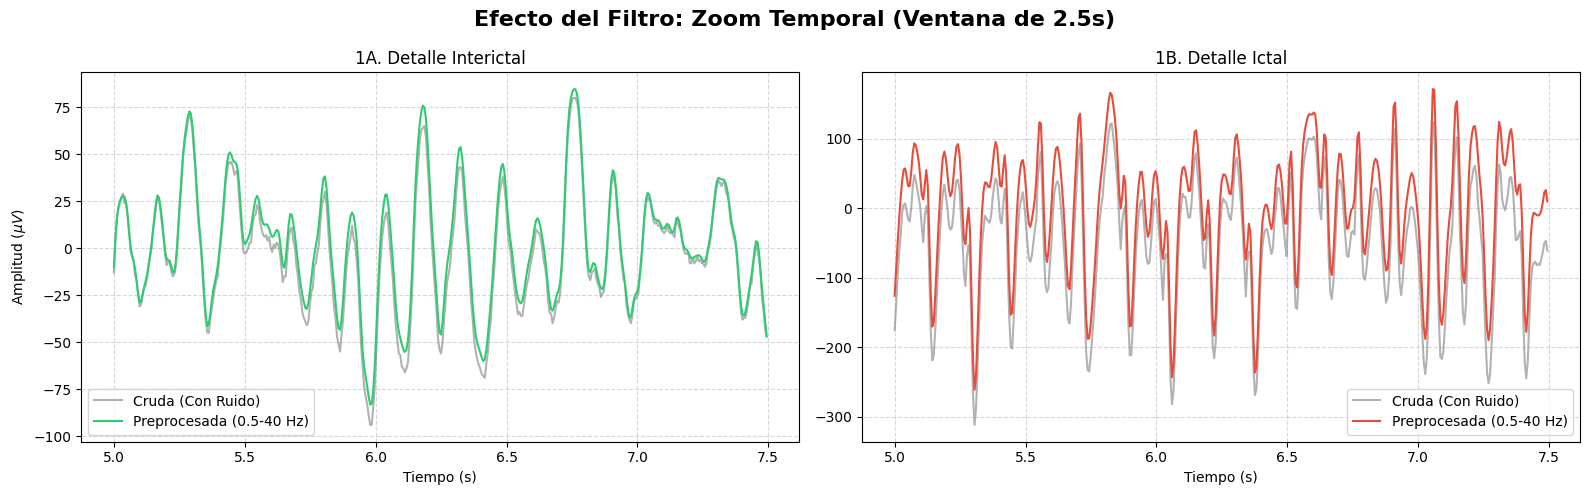

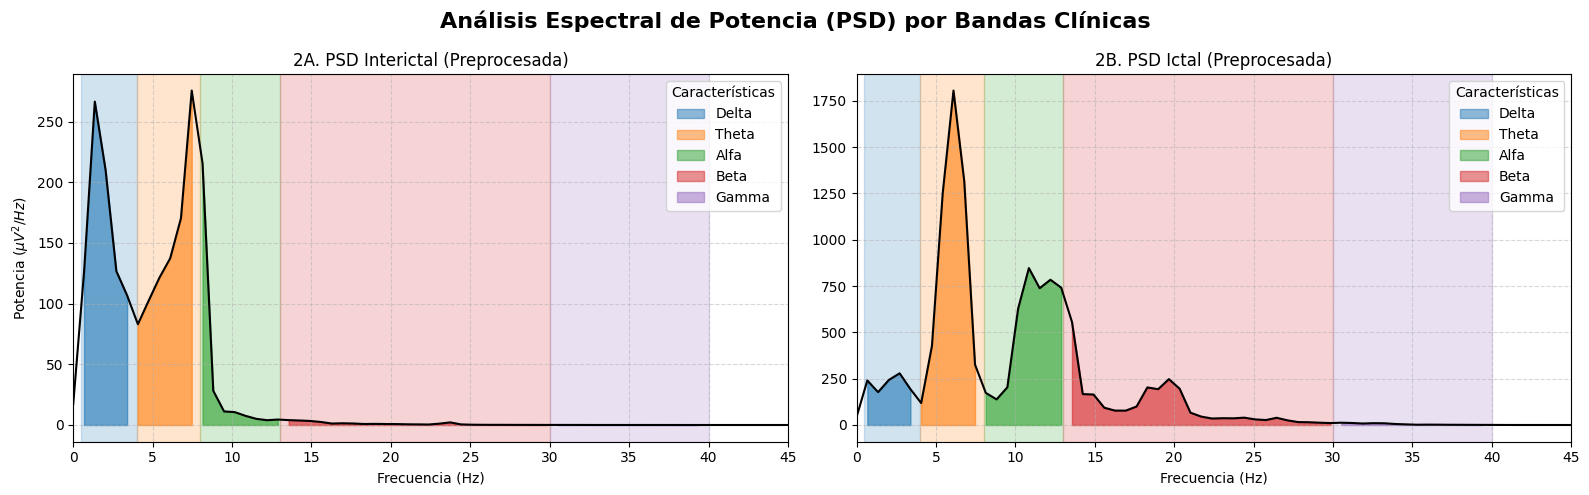


Extrayendo características para todo el dataset...

Relevancia de características (ANOVA F-value):


,Característica,F-Score
3,Line_Length,237.718639
0,Varianza,128.435867
5,P_Theta,112.265699
6,P_Alfa,102.053319
8,P_Gamma,51.102985
7,P_Beta,45.122030
4,P_Delta,42.478657
2,Curtosis,7.098240
1,Asimetria,0.722401



Proceso finalizado. Dimensionalidad final: 6 características por registro.


In [ ]:
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- INICIANDO FASES DE MACHINE LEARNING ---")

# ---------------------------------------------------------
# TRANSICIÓN: Adaptación de tus datos ya cargados
# ---------------------------------------------------------
X_raw = np.array(data_signals)
y_num = np.array([0 if label == 'Interictal' else 1 for label in labels])

# ---------------------------------------------------------
# FASE 2: DIVISIÓN DE DATOS (70% Train, 15% Val, 15% Test)
# ---------------------------------------------------------
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_num, test_size=0.15, stratify=y_num, random_state=42
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

# ---------------------------------------------------------
# FUNCIONES DE PREPROCESAMIENTO Y EXTRACCIÓN
# ---------------------------------------------------------
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alfa': (8, 13), 'Beta': (13, 30), 'Gamma': (30, 40)}
band_colors = {'Delta': '#1f77b4', 'Theta': '#ff7f0e', 'Alfa': '#2ca02c', 'Beta': '#d62728', 'Gamma': '#9467bd'}

# ---------------------------------------------------------
# VISUALIZACIÓN CLÍNICA: Zoom Temporal y PSD por Bandas
# ---------------------------------------------------------
print("\nGenerando gráficas de comprobación metodológica...")

idx_interictal = np.where(y_train == 0)[0][0]
idx_ictal = np.where(y_train == 1)[0][0]

sig_raw_int = X_train_raw[idx_interictal]
sig_filt_int = butter_bandpass_filter(sig_raw_int, 0.5, 40.0, fs)

sig_raw_ict = X_train_raw[idx_ictal]
sig_filt_ict = butter_bandpass_filter(sig_raw_ict, 0.5, 40.0, fs)

time_vector = np.arange(X_train_raw.shape[1]) / fs

# --- GRÁFICA 1: ZOOM TEMPORAL (Superposición en ventana de 2.5 seg) ---
start_idx = int(5.0 * fs)
end_idx = int(7.5 * fs)

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))
fig1.suptitle('Efecto del Filtro: Zoom Temporal (Ventana de 2.5s)', fontsize=16, fontweight='bold')

# Zoom Interictal
axes1[0].plot(time_vector[start_idx:end_idx], sig_raw_int[start_idx:end_idx], color='gray', label='Cruda (Con Ruido)', linewidth=1.5, alpha=0.6)
axes1[0].plot(time_vector[start_idx:end_idx], sig_filt_int[start_idx:end_idx], color='#2ecc71', label='Preprocesada (0.5-40 Hz)', linewidth=1.5)
axes1[0].set_title('1A. Detalle Interictal')
axes1[0].set_xlabel('Tiempo (s)')
axes1[0].set_ylabel(r'Amplitud ($\mu V$)')
axes1[0].legend()
axes1[0].grid(True, linestyle='--', alpha=0.5)

# Zoom Ictal
axes1[1].plot(time_vector[start_idx:end_idx], sig_raw_ict[start_idx:end_idx], color='gray', label='Cruda (Con Ruido)', linewidth=1.5, alpha=0.6)
axes1[1].plot(time_vector[start_idx:end_idx], sig_filt_ict[start_idx:end_idx], color='#e74c3c', label='Preprocesada (0.5-40 Hz)', linewidth=1.5)
axes1[1].set_title('1B. Detalle Ictal')
axes1[1].set_xlabel('Tiempo (s)')
axes1[1].legend()
axes1[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- GRÁFICA 2: ESPECTRO DE POTENCIA (PSD COLOREADO) ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle('Análisis Espectral de Potencia (PSD) por Bandas Clínicas', fontsize=16, fontweight='bold')

signals_for_psd = [
    ('2A. PSD Interictal (Preprocesada)', sig_filt_int),
    ('2B. PSD Ictal (Preprocesada)', sig_filt_ict)
]

for i, (title, sig_filt) in enumerate(signals_for_psd):
    ax_freq = axes2[i]
    freqs, psd = welch(sig_filt, fs=fs, nperseg=256)

    idx_plot = freqs <= 50
    ax_freq.plot(freqs[idx_plot], psd[idx_plot], color='black', linewidth=1.5)

    patches = []
    for band_name, (f_min, f_max) in bands.items():
        color = band_colors[band_name]
        ax_freq.axvspan(f_min, f_max, color=color, alpha=0.2)
        patches.append(mpatches.Patch(color=color, alpha=0.5, label=band_name))

        idx_band = np.logical_and(freqs >= f_min, freqs <= f_max)
        ax_freq.fill_between(freqs[idx_band], psd[idx_band], color=color, alpha=0.6)

    ax_freq.set_title(title)
    ax_freq.set_xlabel('Frecuencia (Hz)')
    if i == 0:
        ax_freq.set_ylabel(r'Potencia ($\mu V^2/Hz$)')
    ax_freq.set_xlim(0, 45)
    ax_freq.legend(handles=patches, loc='upper right', title='Características')
    ax_freq.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FASE 3 y 4: EXTRACCIÓN MASIVA DE CARACTERÍSTICAS
# ---------------------------------------------------------
def extract_features(signal, fs):
    sig_filtered = butter_bandpass_filter(signal, 0.5, 40.0, fs)
    var = np.var(sig_filtered)
    skw = skew(sig_filtered)
    kurt = kurtosis(sig_filtered)
    line_length = np.sum(np.abs(np.diff(sig_filtered)))
    freqs, psd = welch(sig_filtered, fs=fs, nperseg=256)
    features = [var, skw, kurt, line_length]
    for f_min, f_max in bands.values():
        idx = np.logical_and(freqs >= f_min, freqs <= f_max)
        features.append(np.sum(psd[idx]))
    return features

feature_names = ['Varianza', 'Asimetria', 'Curtosis', 'Line_Length',
                 'P_Delta', 'P_Theta', 'P_Alfa', 'P_Beta', 'P_Gamma']

print("\nExtrayendo características para todo el dataset...")
X_train_feat = np.array([extract_features(sig, fs) for sig in X_train_raw])
X_val_feat   = np.array([extract_features(sig, fs) for sig in X_val_raw])
X_test_feat  = np.array([extract_features(sig, fs) for sig in X_test_raw])

# ---------------------------------------------------------
# FASE 5: ESTANDARIZACIÓN Y SELECCIÓN DE CARACTERÍSTICAS
# ---------------------------------------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

df_scores = pd.DataFrame({
    'Característica': feature_names,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)

print("\nRelevancia de características (ANOVA F-value):")
display(df_scores)

# Reducción a las 6 mejores características
k_best = 6
selector_final = SelectKBest(score_func=f_classif, k=k_best)
X_train_final = selector_final.fit_transform(X_train_scaled, y_train)
X_val_final   = selector_final.transform(X_val_scaled)
X_test_final  = selector_final.transform(X_test_scaled)

print(f"\nProceso finalizado. Dimensionalidad final: {X_train_final.shape[1]} características por registro.")


--- GENERANDO VISUALIZACIONES DE SEPARABILIDAD DE CLASES ---


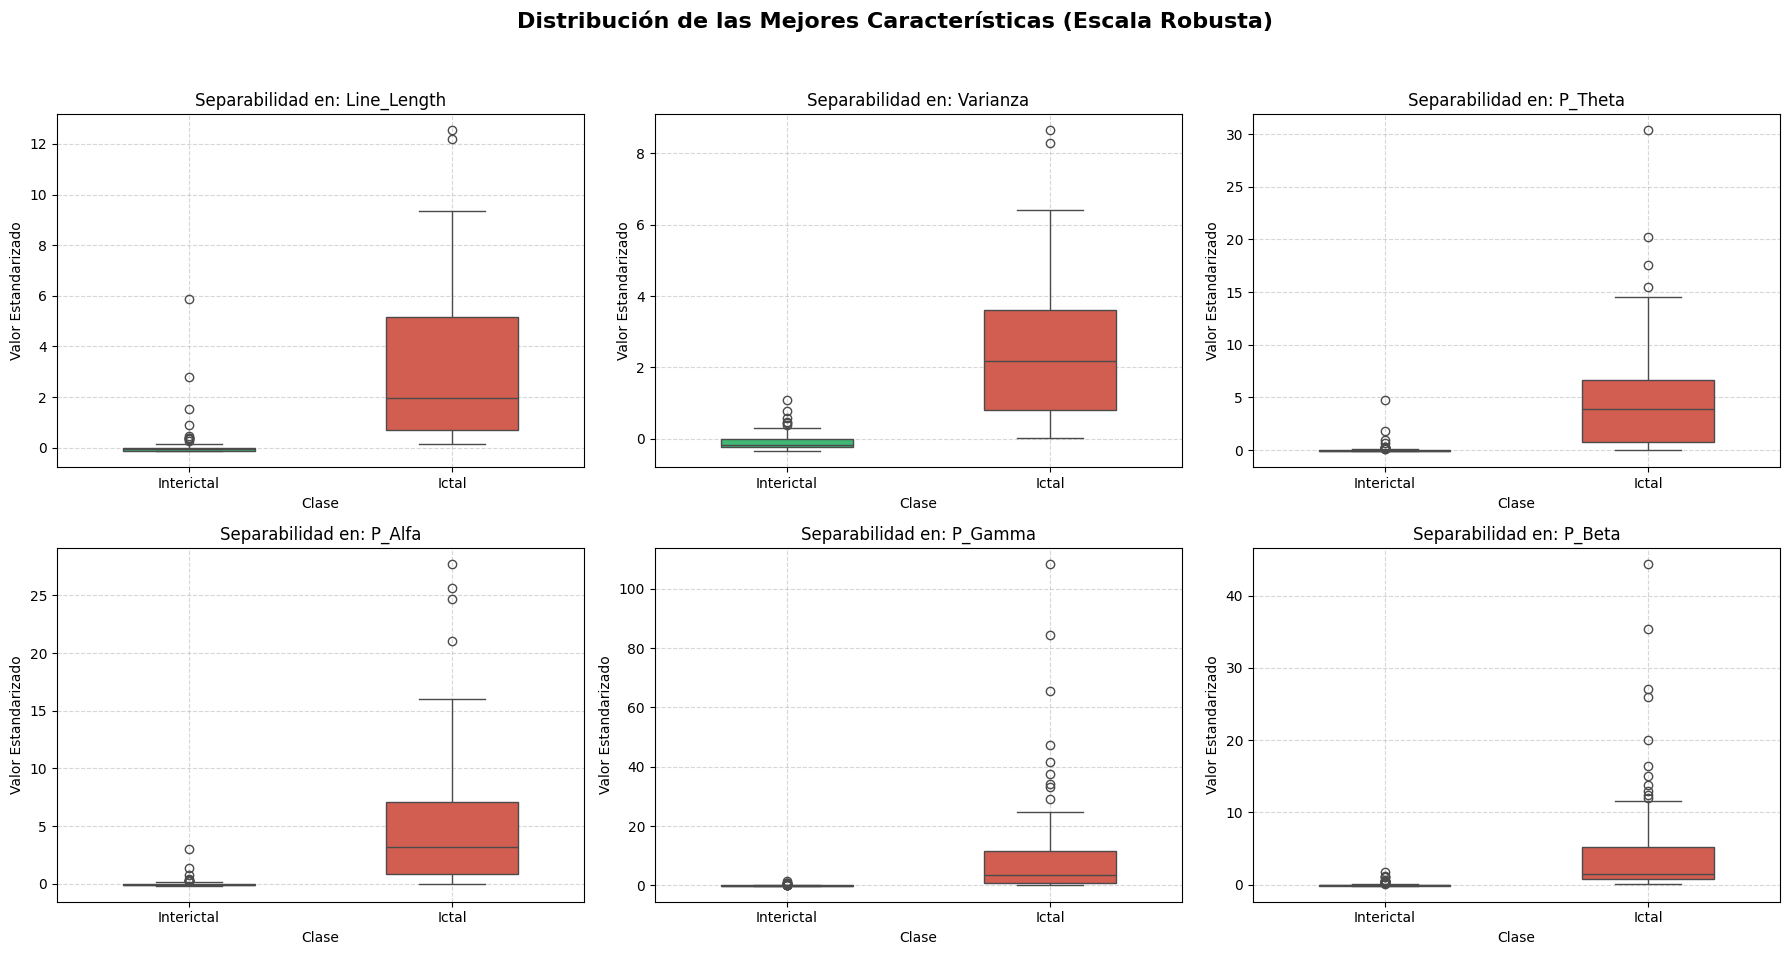

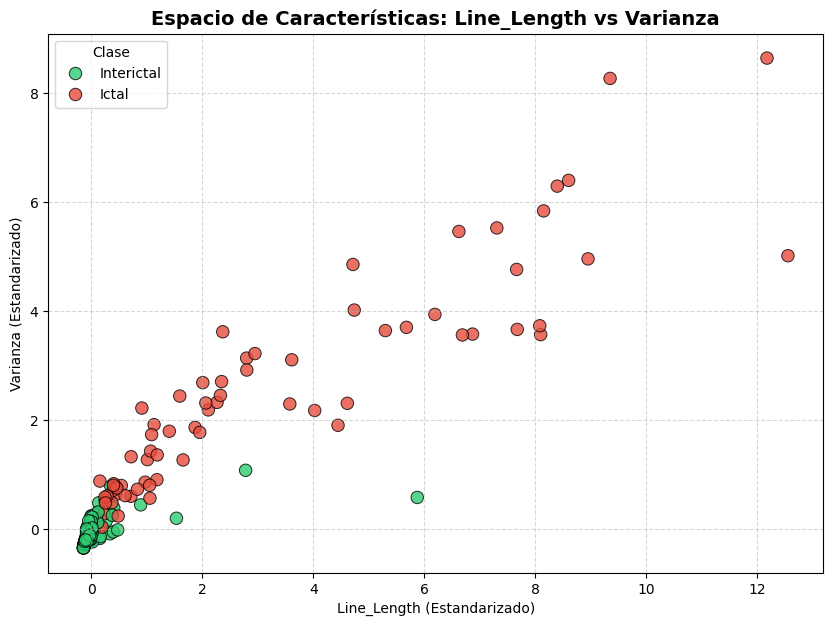

In [ ]:
import seaborn as sns

print("\n--- GENERANDO VISUALIZACIONES DE SEPARABILIDAD DE CLASES ---")

# 1. Recuperar los nombres de las 6 características que ganaron la selección
nombres_seleccionados = df_scores['Característica'].head(k_best).tolist()

# 2. Crear un DataFrame con la Matriz Final de Entrenamiento para graficar
df_train_final = pd.DataFrame(X_train_final, columns=nombres_seleccionados)
df_train_final['Clase'] = ['Ictal' if label == 1 else 'Interictal' for label in y_train]

# --- GRÁFICA 1: BOXPLOTS (Distribución Individual) ---
# Demuestra si la mediana y los rangos intercuartílicos de cada característica se separan por clase
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de las Mejores Características (Escala Robusta)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(nombres_seleccionados):
    # CORRECCIÓN: Se añadió hue='Clase' y legend=False para evitar el FutureWarning
    sns.boxplot(x='Clase', y=feature, hue='Clase', data=df_train_final,
                palette={'Interictal': '#2ecc71', 'Ictal': '#e74c3c'}, ax=axes[i], width=0.5, legend=False)
    axes[i].set_title(f'Separabilidad en: {feature}')
    axes[i].set_ylabel('Valor Estandarizado')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- GRÁFICA 2: SCATTER PLOT (Separación Bidimensional) ---
# Demuestra visualmente cómo interactúan los 2 mejores predictores juntos
top_1 = nombres_seleccionados[0] # Line Length
top_2 = nombres_seleccionados[1] # Varianza

plt.figure(figsize=(10, 7))
sns.scatterplot(x=top_1, y=top_2, hue='Clase', data=df_train_final,
                palette={'Interictal': '#2ecc71', 'Ictal': '#e74c3c'},
                s=80, alpha=0.8, edgecolor='k')

plt.title(f'Espacio de Características: {top_1} vs {top_2}', fontsize=14, fontweight='bold')
plt.xlabel(f'{top_1} (Estandarizado)')
plt.ylabel(f'{top_2} (Estandarizado)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()